Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Graph Colouring

Given an undirected graph G = (V, E), and a set of n colors, is it possible to color each vertex in the
graph with a specific color, such that no edge connects two vertices of the same
color? This is a heavy problem as it requires nN spins - one matrix of spins N(i) for
each colour n where 1 = vertex is coloured with colour n(i) and 0 if not. 

Hamiltonian penalty terms: 
1. Penalises for one vertex having not one colour. 
2. Penalises each time an edge connects two vertices of the same colour. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from helpers.helpers import generate_adjacency_matrix_undirected

In [2]:
# ---- Hamiltonian Penalty Terms ----

def get_ha(x, A):
    """Each vertex must have exactly one colour."""
    N = x.shape[0]
    ha = 0
    for v in range(N):
        row_sum = np.sum(x[v])
        ha += (1 - row_sum) ** 2
    return A * ha

def get_hb(x, adjacency_matrix, A):
    """Penalise edges where both endpoints share the same colour."""
    N, n_colours = x.shape
    hb = 0
    for u in range(N):
        for v in range(u + 1, N):
            if adjacency_matrix[u, v] == 1:
                for i in range(n_colours):
                    hb += x[u, i] * x[v, i]
    return A * hb

def calc_energy(x, adjacency_matrix, A):
    return get_ha(x, A) + get_hb(x, adjacency_matrix, A)

In [3]:
# ---- Metropolis / Simulated Annealing ----

def metropolis(x, adjacency_matrix, A, T_start, steps):
    x = x.copy()
    energy = calc_energy(x, adjacency_matrix, A)
    best_x = x.copy()
    best_energy = energy

    N, n_colours = x.shape

    for step in range(steps):
        v = np.random.randint(0, N)
        c = np.random.randint(0, n_colours)
        x[v, c] = 1 - x[v, c]

        new_energy = calc_energy(x, adjacency_matrix, A)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_x = x.copy()
        else:
            x[v, c] = 1 - x[v, c]

    return best_x, best_energy

In [4]:
# ---- Verification ----

def verify_graph_coloring(x, adjacency_matrix):
    """Check that no edge connects two vertices of the same colour."""
    N, n_colours = x.shape

    # check each vertex has exactly one colour
    for v in range(N):
        assigned = np.sum(x[v])
        if assigned != 1:
            print(f"  Vertex {v} has {int(assigned)} colours (should be 1)")
            return False

    # check no adjacent vertices share a colour
    valid = True
    for u in range(N):
        for v in range(u + 1, N):
            if adjacency_matrix[u, v] == 1:
                for i in range(n_colours):
                    if x[u, i] == 1 and x[v, i] == 1:
                        print(f"  Vertices {u} and {v} both have colour {i}")
                        valid = False

    if valid:
        colour_map = {}
        for v in range(N):
            c = np.where(x[v] == 1)[0][0]
            colour_map[v] = c
        used = len(set(colour_map.values()))
        print(f"VALID {used}-colouring: {colour_map}")
    else:
        print("INVALID colouring")
    return valid

In [5]:
# ---- Plotting ----

def plot_graph_coloring(adjacency_matrix, x):
    N, n_colours = x.shape
    G = nx.from_numpy_array(adjacency_matrix)
    pos = nx.spring_layout(G, seed=42)

    cmap = plt.cm.Set1(np.linspace(0, 1, max(n_colours, 3)))

    node_colours = []
    for v in range(N):
        assigned = np.where(x[v] == 1)[0]
        if len(assigned) == 1:
            node_colours.append(cmap[assigned[0]])
        else:
            node_colours.append('gray')

    # check for conflicts to colour edges
    edge_colours = []
    for u, v in G.edges():
        conflict = False
        for i in range(n_colours):
            if x[u, i] == 1 and x[v, i] == 1:
                conflict = True
        edge_colours.append('red' if conflict else 'lightgray')

    plt.figure(figsize=(6, 6))
    nx.draw_networkx_edges(G, pos, edge_color=edge_colours, width=2)
    nx.draw_networkx_nodes(G, pos, node_color=node_colours, node_size=500,
                           edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=12)

    used = len(set(np.argmax(x, axis=1)))
    plt.title(f"Graph Colouring ({used} colours used)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
# ---- Example 1: Petersen graph (chromatic number = 3) ----

G_petersen = nx.petersen_graph()
adjacency_matrix = nx.to_numpy_array(G_petersen, dtype=np.int64)
N = len(adjacency_matrix)

print(f"Petersen graph: {N} vertices, {G_petersen.number_of_edges()} edges")
print(f"Chromatic number: 3")

Petersen graph: 10 vertices, 15 edges
Chromatic number: 3



3-colouring attempt:
Energy: 0.0 (H=0 means valid colouring)
H_A (one colour per vertex): 0.0
H_B (no same-colour neighbours): 0.0
VALID 3-colouring: {0: np.int64(0), 1: np.int64(1), 2: np.int64(2), 3: np.int64(0), 4: np.int64(1), 5: np.int64(2), 6: np.int64(2), 7: np.int64(1), 8: np.int64(1), 9: np.int64(0)}


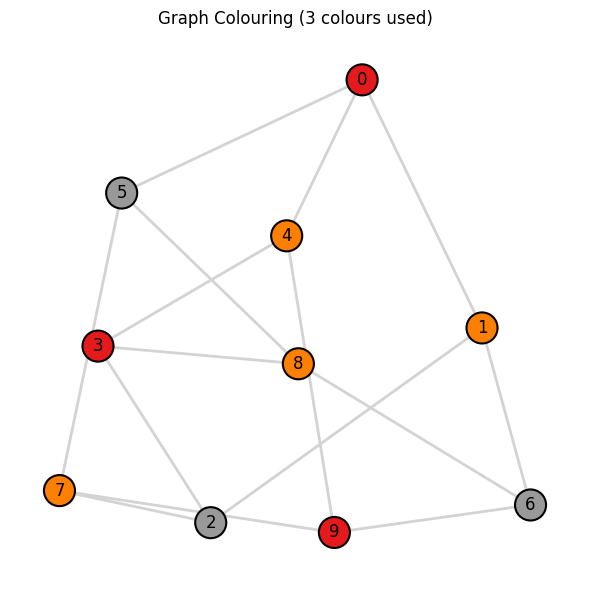

In [7]:
# ---- Try 3-colouring (should succeed) ----

n_colours = 3
A = 1.0
T_start = 5.0
steps = 500000

x = np.random.randint(2, size=(N, n_colours))
best_x, best_energy = metropolis(x, adjacency_matrix, A, T_start, steps)

print(f"\n3-colouring attempt:")
print(f"Energy: {best_energy} (H=0 means valid colouring)")
print(f"H_A (one colour per vertex): {get_ha(best_x, A)}")
print(f"H_B (no same-colour neighbours): {get_hb(best_x, adjacency_matrix, A)}")
verify_graph_coloring(best_x, adjacency_matrix)
plot_graph_coloring(adjacency_matrix, best_x)


2-colouring attempt:
Energy: 3.0 (H>0 means no valid 2-colouring exists)
  Vertex 3 has 0 colours (should be 1)


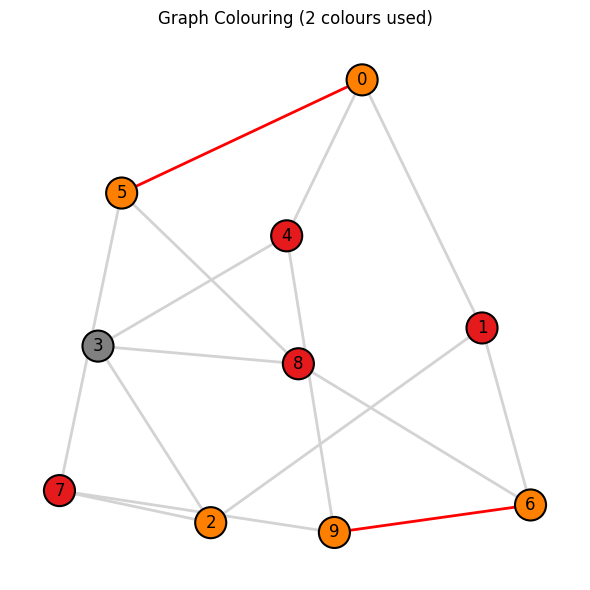

In [8]:
# ---- Try 2-colouring (should fail - Petersen is not bipartite) ----

n_colours = 2
x = np.random.randint(2, size=(N, n_colours))
best_x, best_energy = metropolis(x, adjacency_matrix, A, T_start, steps)

print(f"\n2-colouring attempt:")
print(f"Energy: {best_energy} (H>0 means no valid 2-colouring exists)")
verify_graph_coloring(best_x, adjacency_matrix)
plot_graph_coloring(adjacency_matrix, best_x)

Energy: 0.0
VALID 3-colouring: {0: np.int64(0), 1: np.int64(0), 2: np.int64(2), 3: np.int64(0), 4: np.int64(0), 5: np.int64(1), 6: np.int64(1), 7: np.int64(2), 8: np.int64(2), 9: np.int64(2), 10: np.int64(0), 11: np.int64(1)}


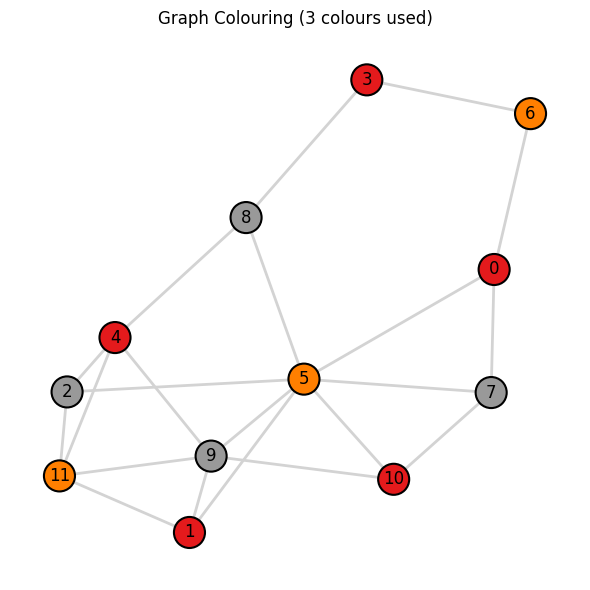

In [9]:
# ---- Example 2: Random graph ----

N = 12
adj_p = 0.3
n_colours = 3
A = 1.0
T_start = 10.0
steps = 1000000

adjacency_matrix = generate_adjacency_matrix_undirected(N, adj_p)
x = np.random.randint(2, size=(N, n_colours))

best_x, best_energy = metropolis(x, adjacency_matrix, A, T_start, steps)

print(f"Energy: {best_energy}")
verify_graph_coloring(best_x, adjacency_matrix)
plot_graph_coloring(adjacency_matrix, best_x)